# AccuSleePy Demo: Train + Calibrate + Evaluate (W&B)

This notebook trains an AccuSleePy SSANN model on the OSF demo dataset already extracted on your NAS, evaluates accuracy on a held-out recording, then applies temperature scaling calibration and evaluates again.

Notes:
- Expected demo data root: `/mnt/nas02/Dataset/accusleep/python_format/extracted/`
- Run with the `torch2` conda kernel (GPU if available).
- W&B uses your existing `wandb login` session.

## 1. Load Configuration & Set Paths

Define project root, data directories, and output paths. Uses `pathlib` for OS-agnostic paths and a timestamped run directory for reproducible outputs.

In [1]:
from __future__ import annotations

import os
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> repo root
DATA_ROOT = Path(os.environ.get("ACCUSLEEP_DATA_ROOT", "/mnt/nas02/Dataset/accusleep/python_format/extracted"))

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = PROJECT_ROOT / "outputs" / f"demo_train_eval_{RUN_ID}"
IMG_DIR = OUT_DIR / "images"
MODEL_DIR = OUT_DIR / "models"
REPORT_DIR = OUT_DIR / "reports"

for p in [OUT_DIR, IMG_DIR, MODEL_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR:", OUT_DIR)

PROJECT_ROOT: /home/yz/Sleep_Analysis
DATA_ROOT: /mnt/nas02/Dataset/accusleep/python_format/extracted
OUT_DIR: /home/yz/Sleep_Analysis/outputs/demo_train_eval_20260207_160133


## 2. Import Project Modules & Verify Environment

Import standard libraries and local `accusleepy` modules. Prints versions and fails fast if core dependencies are missing.

In [2]:
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import wandb

# Make sure repo imports resolve even if not installed as a package
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import accusleepy.constants as c
from accusleepy.fileio import load_config, Recording, load_recording, load_labels
from accusleepy.signal_processing import (
    create_training_images,
    create_eeg_emg_image,
    resample_and_standardize,
)
from accusleepy.classification import train_ssann, score_recording, create_dataloader
from accusleepy.temperature_scaling import ModelWithTemperature
from accusleepy.models import save_model

print("python:", sys.version.split()[0])
print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())
print("wandb:", wandb.__version__)
print("pandas:", pd.__version__)

python: 3.11.13
torch: 2.5.1+cu121 cuda: True
wandb: 0.21.4
pandas: 2.3.2


## 3. Load Raw Sleep Data (CSV/JSON)

In this repository, the "raw" demo data is stored as:
- `recording.parquet`: EEG/EMG time series
- `labels.csv`: per-epoch sleep-stage labels (digits)

We’ll load a small preview and show schemas.

In [3]:
from glob import glob

config = load_config()
brain_state_set = config.brain_state_set
epoch_length = float(config.default_epoch_length)
emg_filter = config.emg_filter
hyper = config.hyperparameters

print("default epoch_length:", epoch_length)
print("scored classes:", brain_state_set.n_classes)
print("mixture_weights:", brain_state_set.mixture_weights)

# Discover demo recordings (prefer 4-hour recordings for runtime)
rec_paths = sorted(glob(str(DATA_ROOT / "4-hour_recordings" / "**" / "recording.parquet"), recursive=True))
print("found 4-hour recordings:", len(rec_paths))
assert len(rec_paths) > 0, f"No recordings found under {DATA_ROOT}"

def label_path_for_recording(recording_path: str) -> str:
    p = Path(recording_path)
    return str(p.with_name("labels.csv"))

# Show one preview
preview_rec = Path(rec_paths[0])
preview_lbl = Path(label_path_for_recording(str(preview_rec)))
print("preview recording:", preview_rec)
print("preview labels:", preview_lbl)

df_rec = pd.read_parquet(preview_rec)
df_lbl = pd.read_csv(preview_lbl)
print("recording.parquet columns:", list(df_rec.columns), "len:", len(df_rec))
print(df_rec.head())
print("labels.csv columns:", list(df_lbl.columns), "len:", len(df_lbl))
print(df_lbl.head())

default epoch_length: 2.5
scored classes: 3
mixture_weights: [0.1  0.35 0.55]
found 4-hour recordings: 50
preview recording: /mnt/nas02/Dataset/accusleep/python_format/extracted/4-hour_recordings/Mouse01/Day1/recording.parquet
preview labels: /mnt/nas02/Dataset/accusleep/python_format/extracted/4-hour_recordings/Mouse01/Day1/labels.csv
recording.parquet columns: ['eeg', 'emg'] len: 7372800
       eeg    emg
0 -163.995 -57.72
1 -186.420 -85.41
2 -113.490 -26.91
3 -119.535 -47.19
4 -103.155 -64.35
labels.csv columns: ['brain_state'] len: 5760
   brain_state
0            1
1            1
2            1
3            1
4            1


## 4. Validate & Clean Sleep Sessions

For EEG/EMG + epoch labels, validation means:
- EEG/EMG lengths exist and match
- label file contains `brain_state`
- inferred sampling rate is plausible
- labels contain enough scored states for training

We’ll flag any problematic recordings and then pick a deterministic train/test split.

In [4]:
import random

SCORED_DIGITS = sorted([b.digit for b in brain_state_set.brain_states if b.is_scored])
UNDEF = c.UNDEFINED_LABEL

def infer_sampling_rate(eeg_len: int, n_epochs: int, epoch_length_sec: float) -> float:
    return float(eeg_len) / (float(n_epochs) * float(epoch_length_sec))


def summarize_recording(recording_path: str) -> dict:
    rp = Path(recording_path)
    lp = Path(label_path_for_recording(str(rp)))
    out = {"recording": str(rp), "labels": str(lp), "ok": False, "reason": None}
    if not lp.exists():
        out["reason"] = "missing labels.csv"
        return out

    try:
        rec_df = pd.read_parquet(rp)
        lbl_df = pd.read_csv(lp)
    except Exception as e:
        out["reason"] = f"load error: {e!r}"
        return out

    if c.BRAIN_STATE_COL not in lbl_df.columns:
        out["reason"] = "labels missing brain_state column"
        return out

    eeg_len = len(rec_df)
    labels = lbl_df[c.BRAIN_STATE_COL].to_numpy()
    n_epochs = len(labels)

    if eeg_len == 0 or n_epochs == 0:
        out["reason"] = "empty recording or labels"
        return out

    sr = infer_sampling_rate(eeg_len, n_epochs, epoch_length)
    out.update({"eeg_len": eeg_len, "n_epochs": n_epochs, "sampling_rate": sr})

    present = sorted(set(int(x) for x in labels if int(x) != UNDEF))
    out["present_digits"] = present

    # Require that all scored classes appear at least once for stable mixture z-scoring during image creation
    if not set(SCORED_DIGITS).issubset(set(present)):
        out["reason"] = f"missing scored digits; need {SCORED_DIGITS}, have {present}"
        return out

    if not (50 <= sr <= 2000):
        out["reason"] = f"implausible sampling_rate {sr:.2f} Hz"
        return out

    out["ok"] = True
    return out

# Validate a subset quickly
summaries = [summarize_recording(p) for p in rec_paths]
ok = [s for s in summaries if s["ok"]]
bad = [s for s in summaries if not s["ok"]]

print("ok recordings:", len(ok))
print("bad recordings:", len(bad))
if bad:
    print("first 5 bad reasons:")
    for s in bad[:5]:
        print("-", Path(s["recording"]).parent, "->", s["reason"])

assert len(ok) >= 2, "Need at least 2 valid recordings to do train/test"

# Deterministic split
rng = random.Random(123)
rng.shuffle(ok)
train_meta, test_meta = ok[0], ok[1]
print("train:", Path(train_meta["recording"]).parent)
print("test :", Path(test_meta["recording"]).parent)

train_rec = Recording(
    name=1,
    recording_file=train_meta["recording"],
    label_file=train_meta["labels"],
    sampling_rate=float(train_meta["sampling_rate"]),
)

test_rec = Recording(
    name=2,
    recording_file=test_meta["recording"],
    label_file=test_meta["labels"],
    sampling_rate=float(test_meta["sampling_rate"]),
)

pd.DataFrame(ok).to_csv(REPORT_DIR / "validated_recordings.csv", index=False)
pd.DataFrame(bad).to_csv(REPORT_DIR / "rejected_recordings.csv", index=False)
print("wrote:", REPORT_DIR / "validated_recordings.csv")

ok recordings: 50
bad recordings: 0
train: /mnt/nas02/Dataset/accusleep/python_format/extracted/4-hour_recordings/Mouse10/Day3
test : /mnt/nas02/Dataset/accusleep/python_format/extracted/4-hour_recordings/Mouse04/Day4
wrote: /home/yz/Sleep_Analysis/outputs/demo_train_eval_20260207_160133/reports/validated_recordings.csv


## 5. Feature Engineering (Durations, Efficiency, Regularity)

For demo purposes we compute simple epoch-level and recording-level features:
- per-state fractions
- total duration (hours)

(Traditional sleep diary metrics like "time in bed" aren’t present in this EEG/EMG dataset.)

In [5]:
def recording_features(rec: Recording) -> dict:
    labels, _ = load_labels(rec.label_file)
    labels = np.asarray(labels, dtype=int)
    valid = labels[labels != UNDEF]
    dur_hours = len(labels) * epoch_length / 3600.0

    frac = {f"frac_digit_{d}": float(np.mean(valid == d)) if len(valid) else 0.0 for d in SCORED_DIGITS}
    return {
        "duration_hours": float(dur_hours),
        "n_epochs": int(len(labels)),
        "n_scored_epochs": int(len(valid)),
        **frac,
    }

train_feat = recording_features(train_rec)
test_feat = recording_features(test_rec)

feat_df = pd.DataFrame([
    {"split": "train", **train_feat},
    {"split": "test", **test_feat},
])
feat_df

,split,duration_hours,n_epochs,n_scored_epochs,frac_digit_1,frac_digit_2,frac_digit_3
0,train,4.0,5760,5760,0.134028,0.271701,0.594271
1,test,4.0,5760,5760,0.118750,0.335243,0.546007


## 6. Compute Sleep Score Metrics

Here we treat the model’s performance metrics as the primary “score metrics”:
- epoch-level accuracy
- per-class accuracy
- confusion matrix

We’ll compute these for:
- an uncalibrated model
- a temperature-calibrated model

In [6]:
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, labels: list[int]) -> np.ndarray:
    idx = {d: i for i, d in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for t, p in zip(y_true, y_pred):
        if t in idx and p in idx:
            cm[idx[t], idx[p]] += 1
    return cm


def per_class_accuracy(y_true: np.ndarray, y_pred: np.ndarray, labels: list[int]) -> dict:
    out = {}
    for d in labels:
        mask = y_true == d
        out[f"acc_digit_{d}"] = float(np.mean(y_pred[mask] == d)) if np.any(mask) else float('nan')
    return out


def robust_mixture_stats(img: np.ndarray, labels_digit: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Convert to class labels and only keep scored epochs
    labels_class = brain_state_set.convert_digit_to_class(labels_digit)
    labels_class = np.asarray(labels_class)

    present_classes = sorted(set(int(x) for x in labels_class if x is not None))
    if len(present_classes) == 0:
        raise ValueError("No scored epochs available for mixture stats")

    # Compute per-class means/vars for present classes only
    means = []
    variances = []
    weights = []
    for cls in present_classes:
        mask = labels_class == cls
        means.append(np.mean(img[:, mask], axis=1))
        variances.append(np.var(img[:, mask], axis=1))
        weights.append(float(brain_state_set.mixture_weights[cls]))

    means = np.asarray(means)
    variances = np.asarray(variances)
    weights = np.asarray(weights, dtype=float)
    weights = weights / np.sum(weights)

    mixture_means = means.T @ weights
    mixture_sds = np.sqrt(
        variances.T @ weights
        + (((mixture_means - np.tile(mixture_means, (len(present_classes), 1))) ** 2).T @ weights)
    )

    # Guard against zeros
    mixture_sds = np.where(mixture_sds == 0, 1.0, mixture_sds)
    return mixture_means, mixture_sds


def evaluate_on_recording(model, rec: Recording, epochs_per_img: int) -> dict:
    eeg, emg = load_recording(rec.recording_file)
    labels_digit, _ = load_labels(rec.label_file)
    labels_digit = np.asarray(labels_digit, dtype=int)

    eeg, emg, sr = resample_and_standardize(eeg=eeg, emg=emg, sampling_rate=rec.sampling_rate, epoch_length=epoch_length)

    # Ensure label length matches number of epochs after standardization
    samples_per_epoch = round(sr * epoch_length)
    n_epochs = int(len(eeg) / samples_per_epoch)
    labels_digit = labels_digit[:n_epochs]

    img = create_eeg_emg_image(eeg, emg, sr, epoch_length, emg_filter)
    mixture_means, mixture_sds = robust_mixture_stats(img, labels_digit)

    pred_digit, conf = score_recording(
        model=model,
        eeg=eeg,
        emg=emg,
        mixture_means=mixture_means,
        mixture_sds=mixture_sds,
        sampling_rate=sr,
        epoch_length=epoch_length,
        epochs_per_img=epochs_per_img,
        brain_state_set=brain_state_set,
        emg_filter=emg_filter,
    )

    pred_digit = np.asarray(pred_digit, dtype=int)
    # Compare only scored epochs
    mask = labels_digit != UNDEF
    y_true = labels_digit[mask]
    y_pred = pred_digit[mask]

    acc = float(np.mean(y_true == y_pred)) if len(y_true) else float('nan')
    cm = confusion_matrix(y_true, y_pred, labels=SCORED_DIGITS)
    per_acc = per_class_accuracy(y_true, y_pred, labels=SCORED_DIGITS)

    return {
        "test_acc": acc,
        "n_eval_epochs": int(len(y_true)),
        **per_acc,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "confidence": np.asarray(conf)[mask],
    }

## 7. Baseline Model (Rule-Based Scoring)

A transparent baseline is to always predict the most frequent scored label from the training recording.

In [7]:
train_labels, _ = load_labels(train_rec.label_file)
train_labels = np.asarray(train_labels, dtype=int)
train_valid = train_labels[train_labels != UNDEF]
majority_digit = int(pd.Series(train_valid).value_counts().idxmax())
print("baseline majority_digit:", majority_digit)

test_labels, _ = load_labels(test_rec.label_file)
test_labels = np.asarray(test_labels, dtype=int)
mask = test_labels != UNDEF
baseline_acc = float(np.mean(test_labels[mask] == majority_digit))
print("baseline test accuracy:", baseline_acc)

baseline majority_digit: 3
baseline test accuracy: 0.5460069444444444


## 8. Train/Test Split & Simple ML Model (e.g., Random Forest)

We train the repository’s intended model (SSANN CNN) using:
- `create_training_images` to build an image dataset
- `train_ssann` to fit the model
- `ModelWithTemperature` to calibrate (optional)

In [8]:
EPOCHS_PER_IMG = 9
MODEL_TYPE = c.DEFAULT_MODEL_TYPE
CALIBRATION_FRACTION = 0.2

# If a previous run exists (e.g., after an error), finalize it.
if wandb.run is not None:
    wandb.finish()

# W&B
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "accusleepy")
WANDB_ENTITY = os.environ.get("WANDB_ENTITY")  # optional

run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name=f"demo_train_eval_{RUN_ID}",
    config={
        "epoch_length": epoch_length,
        "epochs_per_img": EPOCHS_PER_IMG,
        "model_type": MODEL_TYPE,
        "calibration_fraction": CALIBRATION_FRACTION,
        "batch_size": hyper.batch_size,
        "learning_rate": hyper.learning_rate,
        "momentum": hyper.momentum,
        "training_epochs": hyper.training_epochs,
        "train_recording": str(Path(train_rec.recording_file).parent),
        "test_recording": str(Path(test_rec.recording_file).parent),
        "baseline_majority_digit": majority_digit,
        "baseline_test_acc": baseline_acc,
    },
)

# Create training images (skip if already created)
ann_file = IMG_DIR / c.ANNOTATIONS_FILENAME
cal_file = IMG_DIR / c.CALIBRATION_ANNOTATION_FILENAME

if not ann_file.exists():
    print("Creating training images in:", IMG_DIR)
    t0 = time.time()
    failed = create_training_images(
        recordings=[train_rec],
        output_path=str(IMG_DIR),
        epoch_length=epoch_length,
        epochs_per_img=EPOCHS_PER_IMG,
        brain_state_set=brain_state_set,
        model_type=MODEL_TYPE,
        calibration_fraction=CALIBRATION_FRACTION,
        emg_filter=emg_filter,
    )
    assert len(failed) == 0, f"Failed recordings: {failed}"
    wandb.log({"image_build_seconds": float(time.time() - t0)})
else:
    print("Reusing existing training images in:", IMG_DIR)

ann_df = pd.read_csv(ann_file)
cal_df = pd.read_csv(cal_file) if cal_file.exists() else pd.DataFrame()

wandb.log({
    "n_train_images": int(len(ann_df)),
    "n_calib_images": int(len(cal_df)) if len(cal_df) else 0,
})

# Train SSANN
t1 = time.time()
model_uncal = train_ssann(
    annotations_file=str(ann_file),
    img_dir=str(IMG_DIR),
    mixture_weights=brain_state_set.mixture_weights,
    n_classes=brain_state_set.n_classes,
    hyperparameters=hyper,
)
wandb.log({"train_seconds": float(time.time() - t1)})

# Save uncalibrated model
uncal_path = MODEL_DIR / "ssann_uncalibrated.pth"
save_model(
    model=model_uncal,
    filename=str(uncal_path),
    epoch_length=epoch_length,
    epochs_per_img=EPOCHS_PER_IMG,
    model_type=MODEL_TYPE,
    brain_state_set=brain_state_set,
    is_calibrated=False,
)

# Evaluate uncalibrated
res_uncal = evaluate_on_recording(model_uncal, test_rec, epochs_per_img=EPOCHS_PER_IMG)
print("uncalibrated test_acc:", res_uncal["test_acc"])

wandb.log({
    "test_acc_uncalibrated": res_uncal["test_acc"],
    **{f"uncal_{k}": v for k, v in res_uncal.items() if k.startswith("acc_digit_")},
})

# Calibrate with temperature scaling
calib_metrics = {}
model_cal = None
calib_loader = None
if len(cal_df) > 0:
    calib_loader = create_dataloader(
        annotations_file=str(cal_file),
        img_dir=str(IMG_DIR),
        hyperparameters=hyper,
    )

    model_cal = ModelWithTemperature(model_uncal)

    # Recompute NLL/ECE ourselves for logging (set_temperature prints, but doesn't return values)
    device = "cuda" if torch.cuda.is_available() else ("mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")
    nll = torch.nn.CrossEntropyLoss().to(device)

    def _ece(logits: torch.Tensor, labels: torch.Tensor, n_bins: int = 15) -> float:
        softmaxes = torch.nn.functional.softmax(logits, dim=1)
        confidences, predictions = torch.max(softmaxes, 1)
        accuracies = predictions.eq(labels)
        bin_boundaries = torch.linspace(0, 1, n_bins + 1, device=logits.device)
        bin_lowers = bin_boundaries[:-1]
        bin_uppers = bin_boundaries[1:]
        ece = torch.zeros(1, device=logits.device)
        for bl, bu in zip(bin_lowers, bin_uppers):
            in_bin = confidences.gt(bl.item()) * confidences.le(bu.item())
            prop = in_bin.float().mean()
            if prop.item() > 0:
                acc_bin = accuracies[in_bin].float().mean()
                conf_bin = confidences[in_bin].mean()
                ece += torch.abs(conf_bin - acc_bin) * prop
        return float(ece.item())

    # collect logits/labels
    model_uncal.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for x, y in calib_loader:
            x = x.to(device)
            y = y.to(device)
            logits_list.append(model_uncal.to(device)(x))
            labels_list.append(y)
    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)
    calib_metrics["calib_nll_before"] = float(nll(logits, labels).item())
    calib_metrics["calib_ece_before"] = _ece(logits, labels)

    # fit temperature
    model_cal.set_temperature(calib_loader)

    with torch.no_grad():
        scaled = model_cal.temperature_scale(logits)
    calib_metrics["temperature"] = float(model_cal.temperature.detach().cpu().item())
    calib_metrics["calib_nll_after"] = float(nll(scaled, labels).item())
    calib_metrics["calib_ece_after"] = _ece(scaled, labels)

    wandb.log(calib_metrics)

    # Save calibrated model
    cal_path = MODEL_DIR / "ssann_calibrated.pth"
    save_model(
        model=model_cal,
        filename=str(cal_path),
        epoch_length=epoch_length,
        epochs_per_img=EPOCHS_PER_IMG,
        model_type=MODEL_TYPE,
        brain_state_set=brain_state_set,
        is_calibrated=True,
    )

    # Evaluate calibrated
    res_cal = evaluate_on_recording(model_cal, test_rec, epochs_per_img=EPOCHS_PER_IMG)
    print("calibrated test_acc:", res_cal["test_acc"])

    wandb.log({
        "test_acc_calibrated": res_cal["test_acc"],
        **{f"cal_{k}": v for k, v in res_cal.items() if k.startswith("acc_digit_")},
    })
else:
    print("No calibration_set.csv produced; skipping temperature scaling.")

# Log model files as artifacts
artifact = wandb.Artifact("accusleepy_demo_models", type="model")
artifact.add_file(str(uncal_path))
if (MODEL_DIR / "ssann_calibrated.pth").exists():
    artifact.add_file(str(MODEL_DIR / "ssann_calibrated.pth"))
run.log_artifact(artifact)

print("done")

wandb: Currently logged in as: yuanlongzhang94 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Creating training images in: /home/yz/Sleep_Analysis/outputs/demo_train_eval_20260207_160133/images


100%|██████████| 6/6 [00:03<00:00,  1.58it/s]
/home/yz/anaconda3/envs/torch2/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


uncalibrated test_acc: 0.9600694444444444
Before temperature - NLL: 0.108, ECE: 0.019
Optimal temperature: 1.150
After temperature - NLL: 0.109, ECE: 0.019
Validation accuracy: 95.66%
calibrated test_acc: 0.9600694444444444
done


## 9. Evaluation Metrics (MAE/RMSE, Classification Report)

This is a classification task, so we report:
- accuracy
- per-class accuracy
- confusion matrix

In [9]:
# Persist predictions + metrics
metrics = {
    "baseline_test_acc": baseline_acc,
    "test_acc_uncalibrated": res_uncal["test_acc"],
    **{k: v for k, v in res_uncal.items() if k.startswith("acc_digit_")},
    **calib_metrics,
}

with open(REPORT_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

pred_df = pd.DataFrame({
    "y_true": res_uncal["y_true"],
    "y_pred_uncal": res_uncal["y_pred"],
    "conf_uncal": res_uncal["confidence"],
})
if "res_cal" in globals():
    pred_df["y_pred_cal"] = res_cal["y_pred"]
    pred_df["conf_cal"] = res_cal["confidence"]

pred_df.to_csv(REPORT_DIR / "predictions.csv", index=False)
print("wrote:", REPORT_DIR / "metrics.json")
print("wrote:", REPORT_DIR / "predictions.csv")

wrote: /home/yz/Sleep_Analysis/outputs/demo_train_eval_20260207_160133/reports/metrics.json
wrote: /home/yz/Sleep_Analysis/outputs/demo_train_eval_20260207_160133/reports/predictions.csv


## 10. Visualizations (Trends, Distributions, Error Analysis)

We plot:
- state fraction in train vs test
- confusion matrix heatmap

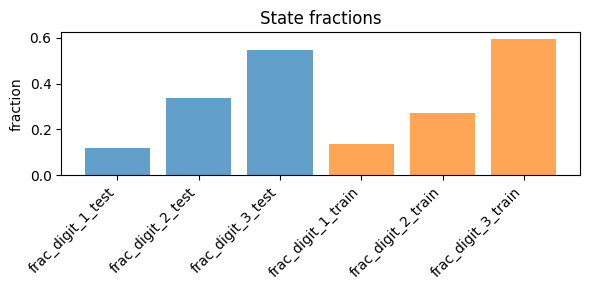

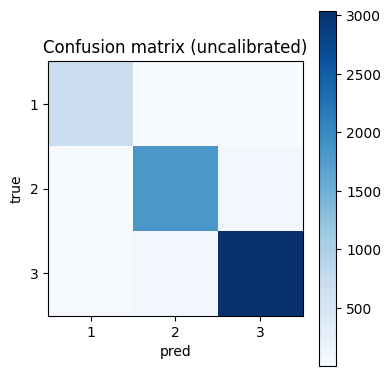

In [10]:
# Bar plot of fractions
plot_df = feat_df.melt(id_vars=["split"], value_vars=[f"frac_digit_{d}" for d in SCORED_DIGITS], var_name="state", value_name="fraction")
plt.figure(figsize=(6, 3))
for split, sub in plot_df.groupby("split"):
    plt.bar(sub["state"] + ("_" + split), sub["fraction"], alpha=0.7, label=split)
plt.xticks(rotation=45, ha="right")
plt.ylabel("fraction")
plt.title("State fractions")
plt.tight_layout()
plt.show()

# Confusion matrix (uncalibrated)
cm = res_uncal["confusion_matrix"]
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(SCORED_DIGITS)), SCORED_DIGITS)
plt.yticks(range(len(SCORED_DIGITS)), SCORED_DIGITS)
plt.xlabel("pred")
plt.ylabel("true")
plt.title("Confusion matrix (uncalibrated)")
plt.tight_layout()
plt.show()

## 11. Export Results (Artifacts + Predictions)

Writes:
- `reports/metrics.json`
- `reports/predictions.csv`
- model weights under `models/`

Also logs the model files as a W&B artifact and finalizes the run.

In [11]:
# Finish W&B
run.summary.update(metrics)
run.finish()

print("Outputs written under:", OUT_DIR)
print("-", REPORT_DIR)
print("-", MODEL_DIR)
print("-", IMG_DIR)

cal_acc_digit_1,▁
cal_acc_digit_2,▁
cal_acc_digit_3,▁
calib_ece_after,▁
calib_ece_before,▁
calib_nll_after,▁
calib_nll_before,▁
image_build_seconds,▁
n_calib_images,▁
n_train_images,▁
+7,...


Outputs written under: /home/yz/Sleep_Analysis/outputs/demo_train_eval_20260207_160133
- /home/yz/Sleep_Analysis/outputs/demo_train_eval_20260207_160133/reports
- /home/yz/Sleep_Analysis/outputs/demo_train_eval_20260207_160133/models
- /home/yz/Sleep_Analysis/outputs/demo_train_eval_20260207_160133/images
